# Pairs Trading: Out-of-Sample Backtest
**Author:** Jon Klein  
**Date:** September 2026  
**Description:** A redo of my first pairs trading project with a strict formation/trading split. Same-sector S&P 500 pairs are screened for cointegration on 2015-2019 data only, and the top 5 are traded on 2020-2024 using parameters frozen at the end of formation.

My first version (`pair_trading.ipynb`) fit the hedge ratio, spread mean, and spread std on the full 2015-2024 window and then backtested on that same window. That means the z-score on any given day was calculated using prices from years later, which the strategy could never have known in real time. When KO/PEP was retested on 2015-2019 alone, the cointegration p-value came back at 0.1039, which fails the 0.05 threshold. The pair only looked cointegrated in hindsight, so we would never have picked it in 2020.

This version fixes that. Everything used to pick pairs and set parameters comes from 2015-2019, and 2020-2024 is only used to see how those choices would have performed.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from itertools import combinations

FORM_START, FORM_END = '2015-01-01', '2019-12-31'
TRADE_START, TRADE_END = '2020-01-01', '2024-12-31'
N_PAIRS = 5
ENTRY_Z, EXIT_Z = 2.0, 0.5
COST_BPS = 5

The universe is current S&P 500 members with their GICS sector. One caveat is that using today's members creates survivorship bias, since companies that were removed or went bankrupt since 2015 are missing. Free point-in-time constituent data isn't available, so this is noted rather than fixed.

Tickers without nearly complete price history over the full 10 years are dropped, which left 458 stocks.

In [2]:
url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv"
sp500 = pd.read_csv(url)
sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-', regex=False)
sector_of = dict(zip(sp500['Symbol'], sp500['GICS Sector']))

data = yf.download(sp500['Symbol'].tolist(), start=FORM_START, end='2025-01-01', auto_adjust=True, progress=False)
prices = data['Close']

# keep tickers with nearly complete history over the whole 10 years, then forward-fill small gaps
prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.98)).ffill().dropna()
print(f"{prices.shape[1]} tickers, {prices.index[0].date()} to {prices.index[-1].date()}")

$FDXF: Data doesn't exist for startDate = 1420088400, endDate = 1735707600
$Q: Data doesn't exist for startDate = 1420088400, endDate = 1735707600
$SNDK: Data doesn't exist for startDate = 1420088400, endDate = 1735707600
$HONA: Data doesn't exist for startDate = 1420088400, endDate = 1735707600

4 Failed downloads:
['FDXF', 'Q', 'SNDK', 'HONA']: Data doesn't exist for startDate = 1420088400, endDate = 1735707600


458 tickers, 2015-01-02 to 2024-12-31


Engle-Granger cointegration test on log prices over the formation period only, testing just pairs within the same sector. My original screener tested every pair (117K tests), and at p < 0.001 roughly 117 pairs would pass by pure chance even if none were truly cointegrated. Restricting to same-sector pairs cut the test count to 11,462, and every pair left has an actual economic reason to move together.

The output compares how many pairs passed against how many we'd expect by chance at each threshold. At p < 0.001 we found 28 against 11.5 expected, so there's a real excess, but a good chunk of even the best pairs could still be noise. The trading period is what tells us which ones were real.

In [3]:
form = np.log(prices.loc[FORM_START:FORM_END])

results = []
for sector in sorted(set(sector_of[t] for t in prices.columns)):
    names = [t for t in prices.columns if sector_of[t] == sector]
    for a, b in combinations(names, 2):
        try:
            p = coint(form[a], form[b])[1]
            results.append((sector, a, b, p))
        except Exception:
            pass

screen = pd.DataFrame(results, columns=['Sector', 'Stock1', 'Stock2', 'p']).sort_values('p').reset_index(drop=True)
n_tests = len(screen)
print(f"Pairs tested: {n_tests:,}")
for thr in [0.05, 0.01, 0.001]:
    print(f"p < {thr}: {(screen.p < thr).sum():>5} found vs {n_tests*thr:>7.1f} expected by chance")
screen.head(15)

Pairs tested: 11,462
p < 0.05:   849 found vs   573.1 expected by chance
p < 0.01:   202 found vs   114.6 expected by chance
p < 0.001:    28 found vs    11.5 expected by chance


,Sector,Stock1,Stock2,p
0,Health Care,PODD,ZTS,0.000009
1,Health Care,PODD,RMD,0.000012
2,Health Care,BDX,ISRG,0.000064
3,Real Estate,AMT,CCI,0.000070
4,Industrials,CPRT,CTAS,0.000121
5,Financials,NTRS,RF,0.000175
6,Industrials,ETN,RTX,0.000210
7,Financials,MSCI,V,0.000210
8,Health Care,BAX,SYK,0.000241
9,Health Care,CAH,CRL,0.000290


The top 5 pairs by p-value are picked, skipping any pair that reuses a stock already picked so one name can't dominate the portfolio (this is why PODD/RMD was skipped, since PODD was already in ZTS/PODD).

For each pair, the hedge ratio comes from an OLS regression of one stock's log price on the other's, using formation data only. The formation spread then gives us the mean and std used to calculate z-scores. These three numbers are frozen and are the only things the trading period is allowed to use.

In [4]:
picked, used = [], set()
for _, r in screen.iterrows():
    if r.Stock1 in used or r.Stock2 in used:
        continue
    picked.append(r); used |= {r.Stock1, r.Stock2}
    if len(picked) == N_PAIRS:
        break

params = []
for r in picked:
    x, y = form[r.Stock1], form[r.Stock2]
    beta = sm.OLS(y, sm.add_constant(x)).fit().params[r.Stock1]
    spread = y - beta * x
    params.append(dict(pair=f"{r.Stock2}/{r.Stock1}", x=r.Stock1, y=r.Stock2, sector=r.Sector,
                       form_p=r.p, beta=beta, mu=spread.mean(), sd=spread.std()))
params = pd.DataFrame(params)
params

,pair,x,y,sector,form_p,beta,mu,sd
0,ZTS/PODD,PODD,ZTS,Health Care,0.000009,0.643008,1.513949,0.068825
1,ISRG/BDX,BDX,ISRG,Health Care,0.000064,1.911655,-4.638442,0.069866
2,CCI/AMT,AMT,CCI,Real Estate,0.000070,0.713743,0.906259,0.029756
3,CTAS/CPRT,CPRT,CTAS,Industrials,0.000121,0.767689,1.775500,0.047283
4,RF/NTRS,NTRS,RF,Financials,0.000175,1.561756,-4.311959,0.056907


Same trading rules as the original project. When the z-score goes above +2 we short the spread, below -2 we go long the spread, and we exit when it comes back within 0.5 of the mean.

The original version had a bug in the exit logic. Positions were set with `ffill()` and then zeroed on days where |z| < 0.5, but once z drifted back above 0.5 the old position came back without ever crossing ±2 again. Here, position is tracked day by day in a loop, so once we exit we stay flat until a new entry signal.

Each pair's position is sized so the two legs add up to 1 unit of capital. Returns use the previous day's position times today's stock returns (the `.shift(1)`), so we only act on information available at the start of each day. Transaction costs are 5 bps every time the position changes.

In [5]:
def positions(z, entry=ENTRY_Z, exit_=EXIT_Z):
    pos, out = 0, []
    for v in z:
        if pos == 0:
            if v > entry: pos = -1
            elif v < -entry: pos = 1
        elif abs(v) < exit_:
            pos = 0
        out.append(pos)
    return pd.Series(out, index=z.index)

trade_px = prices.loc[TRADE_START:TRADE_END]
rets = trade_px.pct_change().fillna(0)

gross, net, zs, trades = {}, {}, {}, {}
for p in params.itertuples():
    spread = np.log(trade_px[p.y]) - p.beta * np.log(trade_px[p.x])
    z = (spread - p.mu) / p.sd                 # frozen formation mean and std
    pos = positions(z)
    wy, wx = 1 / (1 + abs(p.beta)), p.beta / (1 + abs(p.beta))
    g = pos.shift(1).fillna(0) * (wy * rets[p.y] - wx * rets[p.x])
    cost = pos.diff().abs().fillna(0) * COST_BPS / 1e4
    gross[p.pair], net[p.pair], zs[p.pair] = g, g - cost, z
    trades[p.pair] = int((pos.diff().fillna(0) != 0).sum())

gross, net = pd.DataFrame(gross), pd.DataFrame(net)

Results for the trading period (2020-2024), which the strategy never saw during formation.

In [6]:
def stats(r):
    eq = (1 + r).cumprod()
    yrs = len(r) / 252
    return pd.Series({
        'Ann. return': eq.iloc[-1] ** (1 / yrs) - 1,
        'Ann. vol': r.std() * np.sqrt(252),
        'Sharpe': r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan,
        'Max drawdown': (eq / eq.cummax() - 1).min(),
    })

port_gross, port_net = gross.mean(axis=1), net.mean(axis=1)
summary = pd.DataFrame({'Portfolio (gross)': stats(port_gross), 'Portfolio (net 5 bps)': stats(port_net)})
per_pair = pd.DataFrame({k: stats(net[k]) for k in net}).T
per_pair['Trades'] = pd.Series(trades)
per_pair['Formation p'] = params.set_index('pair')['form_p']
per_pair['Trading p'] = [coint(np.log(trade_px[p.x]), np.log(trade_px[p.y]))[1] for p in params.itertuples()]

print(summary.round(3)); print(); print(per_pair.round(3))

              Portfolio (gross)  Portfolio (net 5 bps)
Ann. return               0.041                  0.040
Ann. vol                  0.058                  0.058
Sharpe                    0.721                  0.702
Max drawdown             -0.103                 -0.103

           Ann. return  Ann. vol  Sharpe  Max drawdown  Trades  Formation p  \
ZTS/PODD         0.095     0.163   0.636        -0.174      12          0.0   
ISRG/BDX        -0.013     0.149  -0.012        -0.333      13          0.0   
CCI/AMT         -0.006     0.087  -0.028        -0.145       5          0.0   
CTAS/CPRT        0.022     0.118   0.244        -0.249       9          0.0   
RF/NTRS          0.071     0.133   0.577        -0.203      18          0.0   

           Trading p  
ZTS/PODD       0.224  
ISRG/BDX       0.003  
CCI/AMT        0.152  
CTAS/CPRT      0.232  
RF/NTRS        0.390  


The trading p-value re-tests cointegration on 2020-2024. It isn't used to pick or tune anything, it just shows which formation relationships actually held up.

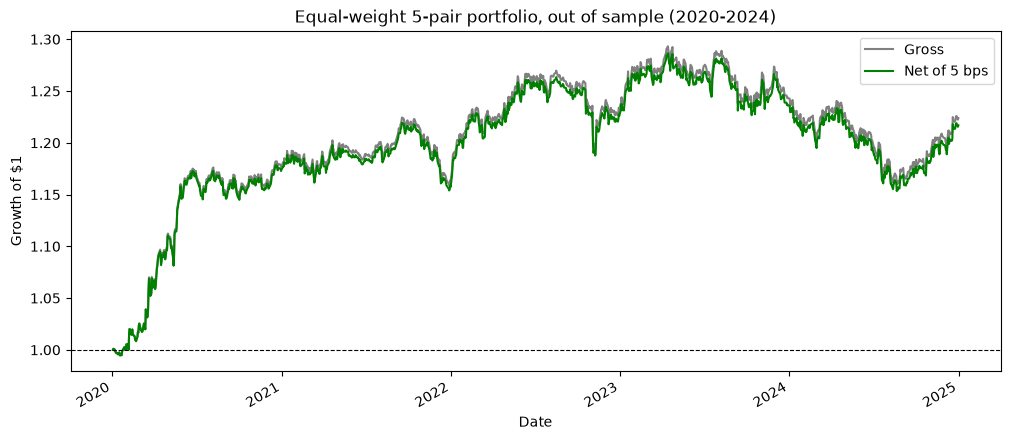

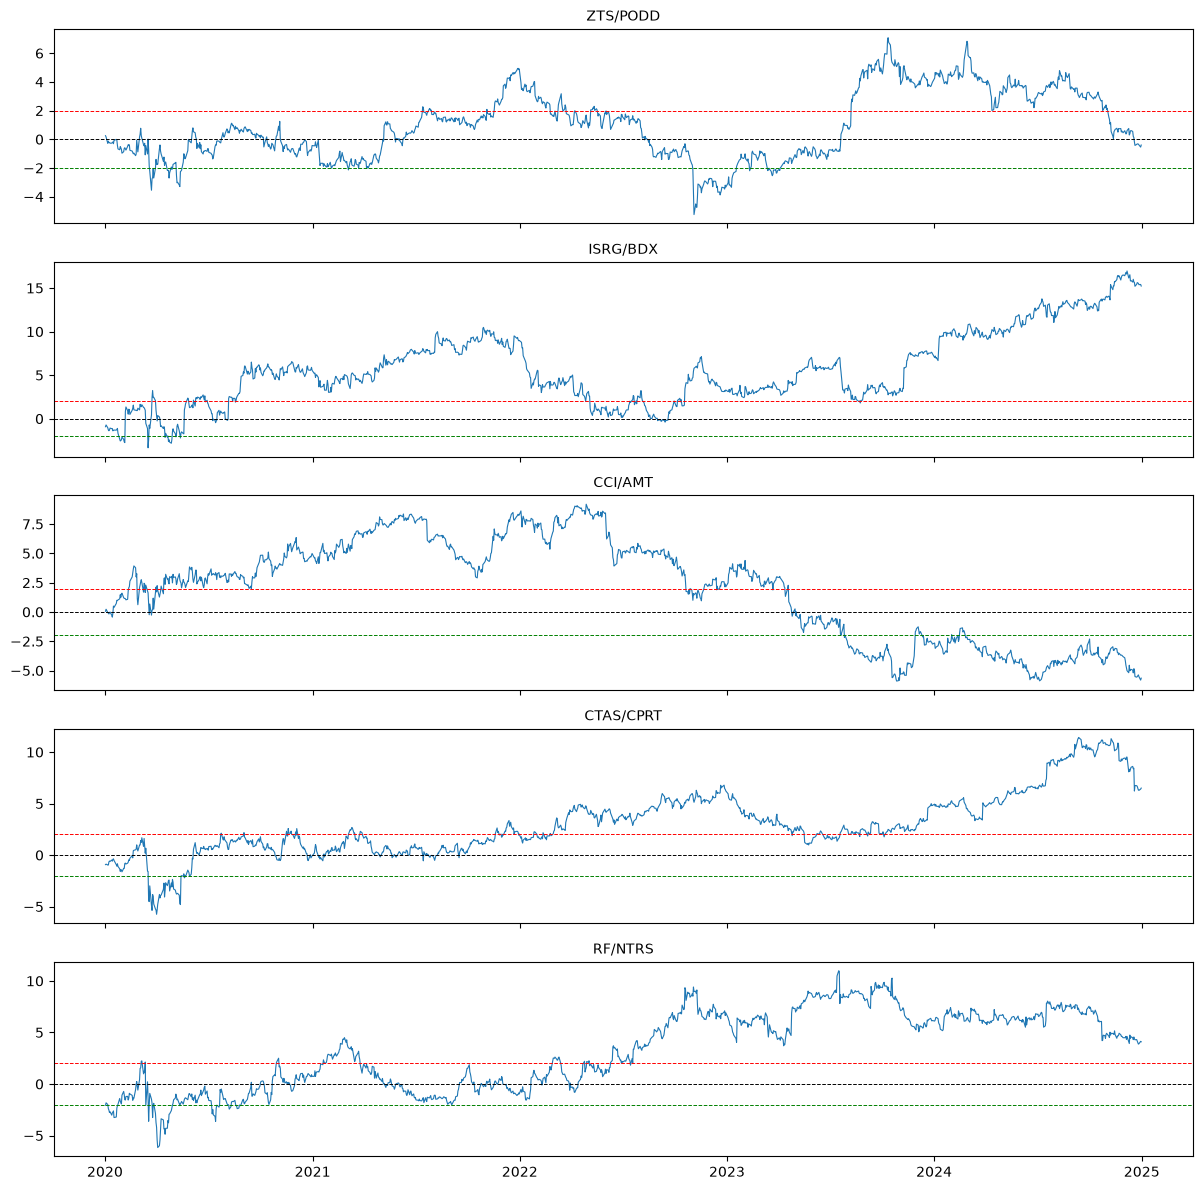

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
(1 + port_gross).cumprod().plot(ax=ax, label='Gross', color='gray')
(1 + port_net).cumprod().plot(ax=ax, label='Net of 5 bps', color='green')
ax.axhline(1, color='black', lw=0.8, ls='--')
ax.set_title('Equal-weight 5-pair portfolio, out of sample (2020-2024)')
ax.set_ylabel('Growth of $1'); ax.legend(); plt.show()

fig, axes = plt.subplots(len(zs), 1, figsize=(12, 2.4 * len(zs)), sharex=True)
for ax, (k, z) in zip(np.atleast_1d(axes), zs.items()):
    ax.plot(z, lw=0.8); ax.set_title(k, fontsize=10)
    for lvl, c in [(ENTRY_Z, 'red'), (-ENTRY_Z, 'green'), (0, 'black')]:
        ax.axhline(lvl, color=c, ls='--', lw=0.7)
plt.tight_layout(); plt.show()

**Takeaways**

The equal-weight portfolio returned 4.0% a year net of costs with a Sharpe ratio of 0.70 and a max drawdown of -10.3%. Costs barely mattered (Sharpe 0.72 gross vs 0.70 net) because each pair only traded 5 to 18 times over five years.

A Sharpe of 0.70 over five years isn't statistically distinguishable from zero though. The standard error of an annualized Sharpe is roughly 1 divided by the square root of the number of years, about 0.45 here, so 0.70 is only around 1.5 standard errors from zero. With 5 pairs and a single test window, luck can't be ruled out.

The per-pair results are more telling. Only 1 of the 5 pairs (ISRG/BDX, p = 0.003) was still cointegrated in the trading period, and it lost money. The two best performers, ZTS/PODD and RF/NTRS, had trading p-values of 0.22 and 0.39, meaning their relationships broke down, and the profit came from spreads happening to revert rather than from a stable relationship. This lines up with the screen results: most formation-period cointegration doesn't survive, and the 2020 COVID crash is where a lot of these relationships changed.

Compared to the original KO/PEP backtest (Sharpe 0.44, fully in-sample), this is a more honest number, but the main finding is that cointegration found in one period is a weak predictor of cointegration in the next.

**Limitations:** survivorship bias from using current constituents, parameters are never re-estimated after formation (a rolling window would adapt but adds more choices), only one 5-year test window, and no borrow costs on the short leg.